<a href="https://colab.research.google.com/github/Elamathi995/LLM/blob/main/LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
       C1  C2  C3   D1   D2   D3
Gene                            
TP53   47  55  42   78  116   88
BRCA1  52  58  43  105   92   96
EGFR   46  49  52  104   84   95
MYC    45  49  43  105  100  104
PTEN   52  52  46  106  120   95

Differential Expression Results:
    Gene    log2FC    pvalue  adj_pval
0   TP53  0.955146  0.018495  0.018495
1  BRCA1  0.924051  0.001305  0.003366
2   EGFR  0.931053  0.001683  0.003366
3    MYC  1.156119  0.000016  0.000326
4   PTEN  1.082462  0.001613  0.003366

Selected Genes for Analysis:
['TP53', 'BRCA1', 'EGFR', 'MYC', 'PTEN', 'AKT1', 'KRAS', 'PIK3CA', 'MAPK1', 'CDK2', 'CDK4', 'RB1', 'BRAF', 'MTOR', 'VEGFA', 'JUN', 'FOS', 'STAT3', 'SMAD4', 'ERBB2']

LLM-style JSON Output:
{
  "genes": [
    "TP53",
    "BRCA1",
    "EGFR",
    "MYC",
    "PTEN",
    "AKT1",
    "KRAS",
    "PIK3CA",
    "MAPK1",
    "CDK2",
    "CDK4",
    "RB1",
    "BRAF",
    "MTOR",
    "VEGFA",
    "JUN",
    "FOS",
    "STAT3",
    "SMAD4",
    "ERBB2"
  ],
  

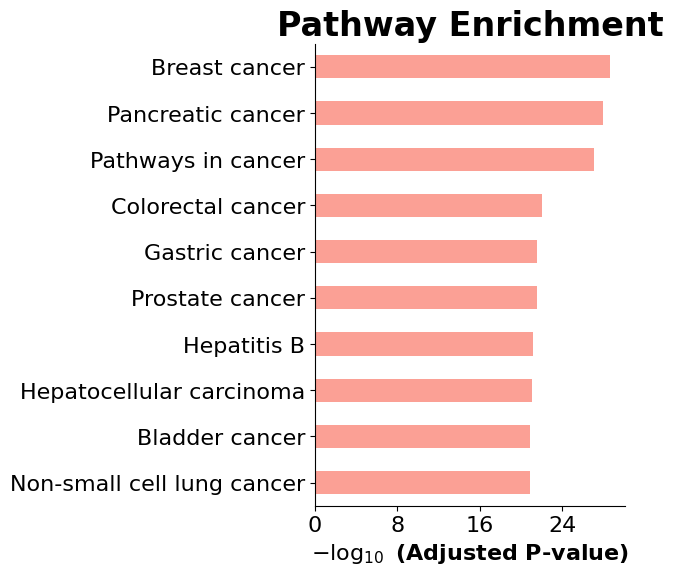


Files saved:
- DEG_results.csv
- enrichment_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ==========================================
# STEP 0: Install Required Packages
# ==========================================
!pip install pandas numpy matplotlib gseapy statsmodels scipy -q

# ==========================================
# STEP 1: Create Dataset (Simulated RNA-seq)
# ==========================================
import pandas as pd
import numpy as np

np.random.seed(42)

genes = ["TP53","BRCA1","EGFR","MYC","PTEN","AKT1","KRAS","PIK3CA",
         "MAPK1","CDK2","CDK4","RB1","BRAF","MTOR","VEGFA","JUN",
         "FOS","STAT3","SMAD4","ERBB2"]

# Increase difference → better DEG detection
control = np.random.poisson(lam=50, size=(20,3))
disease = np.random.poisson(lam=100, size=(20,3))  # increased

df_control = pd.DataFrame(control, columns=["C1","C2","C3"])
df_disease = pd.DataFrame(disease, columns=["D1","D2","D3"])

df = pd.concat([df_control, df_disease], axis=1)
df["Gene"] = genes
df = df.set_index("Gene")

print("Dataset Preview:")
print(df.head())


# ==========================================
# STEP 2: Differential Expression Analysis
# ==========================================
from scipy.stats import ttest_ind

results = []

for gene in df.index:
    ctrl = df.loc[gene, ["C1","C2","C3"]]
    dis = df.loc[gene, ["D1","D2","D3"]]

    log2fc = np.log2(dis.mean() + 1) - np.log2(ctrl.mean() + 1)
    pval = ttest_ind(ctrl, dis).pvalue

    results.append([gene, log2fc, pval])

deg = pd.DataFrame(results, columns=["Gene","log2FC","pvalue"])

# Adjust p-values
from statsmodels.stats.multitest import multipletests
deg["adj_pval"] = multipletests(deg["pvalue"], method='fdr_bh')[1]

print("\nDifferential Expression Results:")
print(deg.head())


# ==========================================
# STEP 3: Select Significant Genes (FIXED)
# ==========================================
deg_filtered = deg[(abs(deg["log2FC"]) > 0.5) & (deg["adj_pval"] < 0.1)]

# If still low genes → take top 10
if len(deg_filtered) < 5:
    deg_filtered = deg.sort_values("adj_pval").head(10)

gene_list = deg_filtered["Gene"].tolist()

print("\nSelected Genes for Analysis:")
print(gene_list)


# ==========================================
# STEP 4: Convert to JSON (LLM-style)
# ==========================================
import json

llm_output = json.dumps({
    "genes": gene_list,
    "analysis": "Differential expression",
    "organism": "human"
}, indent=2)

print("\nLLM-style JSON Output:")
print(llm_output)


# ==========================================
# STEP 5: Parse JSON
# ==========================================
parsed = json.loads(llm_output)
genes_for_analysis = parsed["genes"]


# ==========================================
# STEP 6: Enrichment Analysis (FIXED)
# ==========================================
import gseapy as gp

if len(genes_for_analysis) >= 5:
    enr = gp.enrichr(
        gene_list=genes_for_analysis,
        organism='human',   # ✅ FIXED
        gene_sets='KEGG_2021_Human'
    )

    enr_results = enr.results
    print("\nTop Enriched Pathways:")
    print(enr_results.head())
else:
    print("\n⚠️ Not enough genes for enrichment")
    enr_results = pd.DataFrame()


# ==========================================
# STEP 7: Visualization
# ==========================================
import matplotlib.pyplot as plt

if not enr_results.empty:
    gp.barplot(enr_results, title='Pathway Enrichment', cutoff=0.5)
    plt.show()


# ==========================================
# STEP 8: Save Results
# ==========================================
deg.to_csv("DEG_results.csv", index=False)

if not enr_results.empty:
    enr_results.to_csv("enrichment_results.csv", index=False)

print("\nFiles saved:")
print("- DEG_results.csv")
print("- enrichment_results.csv")


# ==========================================
# STEP 9: Download Files
# ==========================================
from google.colab import files

files.download("DEG_results.csv")

if not enr_results.empty:
    files.download("enrichment_results.csv")

In [4]:
# ==========================================
# STEP 0: Install Packages
# ==========================================
!pip install GEOparse pandas numpy matplotlib gseapy statsmodels scipy -q

# ==========================================
# STEP 1: Download GEO Dataset
# ==========================================
import GEOparse

print("Downloading GEO dataset...")
gse = GEOparse.get_GEO("GSE2034", destdir=".")

print("GEO dataset loaded")

# ==========================================
# STEP 2: Extract Expression Data
# ==========================================
import pandas as pd

samples = gse.gsms

data_list = []
for gsm_name, gsm in samples.items():
    df = gsm.table[["ID_REF", "VALUE"]]
    df.columns = ["Gene", gsm_name]
    data_list.append(df)

# Merge all samples
expr = data_list[0]
for df in data_list[1:]:
    expr = expr.merge(df, on="Gene")

expr = expr.set_index("Gene")

print("Expression matrix shape:", expr.shape)


# ==========================================
# STEP 3: Create Conditions (Control vs Disease)
# ==========================================
# NOTE: For demo, split samples into 2 groups
cols = expr.columns.tolist()

control_cols = cols[:len(cols)//2]
disease_cols = cols[len(cols)//2:]

print("Control samples:", len(control_cols))
print("Disease samples:", len(disease_cols))


# ==========================================
# STEP 4: Differential Expression
# ==========================================
from scipy.stats import ttest_ind
import numpy as np

results = []

for gene in expr.index:
    ctrl = expr.loc[gene, control_cols]
    dis = expr.loc[gene, disease_cols]

    # Handle missing values
    ctrl = pd.to_numeric(ctrl, errors='coerce')
    dis = pd.to_numeric(dis, errors='coerce')

    ctrl = ctrl.dropna()
    dis = dis.dropna()

    if len(ctrl) > 2 and len(dis) > 2:
        log2fc = np.log2(dis.mean() + 1) - np.log2(ctrl.mean() + 1)
        pval = ttest_ind(ctrl, dis).pvalue
        results.append([gene, log2fc, pval])

deg = pd.DataFrame(results, columns=["Gene","log2FC","pvalue"])

# Adjust p-values
from statsmodels.stats.multitest import multipletests
deg["adj_pval"] = multipletests(deg["pvalue"], method='fdr_bh')[1]

print("\nDEG results preview:")
print(deg.head())


# ==========================================
# STEP 5: Select Significant Genes
# ==========================================
deg_filtered = deg[(abs(deg["log2FC"]) > 1) & (deg["adj_pval"] < 0.05)]

# Ensure enough genes
if len(deg_filtered) < 10:
    deg_filtered = deg.sort_values("adj_pval").head(50)

gene_list = deg_filtered["Gene"].tolist()

print("\nSelected gene count:", len(gene_list))


# ==========================================
# STEP 6: 🔥 LLM JSON OUTPUT (CORE)
# ==========================================
import json

llm_output = json.dumps({
    "genes": gene_list,
    "organism": "human",
    "source": "GEO differential expression"
}, indent=2)

print("\nLLM JSON Output:")
print(llm_output[:500])  # preview


# ==========================================
# STEP 7: ✅ PARSE JSON → PYTHON DICT
# ==========================================
parsed = json.loads(llm_output)

genes_from_llm = parsed["genes"]

print("\nParsed gene count:", len(genes_from_llm))


# ==========================================
# STEP 8: Enrichment Analysis
# ==========================================
import gseapy as gp

if len(genes_from_llm) >= 10:
    enr = gp.enrichr(
        gene_list=genes_from_llm,
        organism='human',
        gene_sets='KEGG_2021_Human'
    )

    enr_results = enr.results
    print("\nTop pathways:")
    print(enr_results.head())

else:
    print("Not enough genes")
    enr_results = pd.DataFrame()


# ==========================================
# STEP 9: Visualization
# ==========================================
import matplotlib.pyplot as plt

if not enr_results.empty:
    gp.barplot(enr_results, title='Pathway Enrichment', cutoff=0.5)
    plt.show()


# ==========================================
# STEP 10: Save Results
# ==========================================
deg.to_csv("GEO_DEG_results.csv", index=False)

if not enr_results.empty:
    enr_results.to_csv("GEO_enrichment_results.csv", index=False)

print("\nFiles saved!")


# ==========================================
# STEP 11: Download Files
# ==========================================
from google.colab import files

files.download("GEO_DEG_results.csv")

if not enr_results.empty:
    files.download("GEO_enrichment_results.csv")

16-Apr-2026 06:03:46 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
16-Apr-2026 06:03:46 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/soft/GSE2034_family.soft.gz to ./GSE2034_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/soft/GSE2034_family.soft.gz to ./GSE2034_family.soft.gz


100%|██████████| 62.2M/62.2M [00:00<00:00, 132MB/s]
16-Apr-2026 06:03:46 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
16-Apr-2026 06:03:46 DEBUG downloader - Moving /tmp/tmpbi9l2nn5 to /content/GSE2034_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpbi9l2nn5 to /content/GSE2034_family.soft.gz
16-Apr-2026 06:03:46 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/soft/GSE2034_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/soft/GSE2034_family.soft.gz
16-Apr-2026 06:03:47 INFO GEOparse - Parsing ./GSE2034_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE2034_family.soft.gz: 
16-Apr-2026 06:03:47 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
16-Apr-2026 06:03:47 DEBUG GEOparse - SERIES: GSE2034
DEBUG:GEOparse:SERIES: GSE2034
16-Apr-2026 06:03:47 DEBUG GEOparse - PLATFORM: GPL96
DEBUG:GEOparse:PLATFORM: GPL96
16-Apr-2026 06:03:48 DEBU

GEO dataset loaded
Expression matrix shape: (22283, 286)
Control samples: 143
Disease samples: 143

DEG results preview:
             Gene    log2FC    pvalue  adj_pval
0  AFFX-BioB-5_at  0.248501  0.002722  0.224727
1  AFFX-BioB-M_at  0.315993  0.000228  0.121052
2  AFFX-BioB-3_at  0.251785  0.004900  0.259912
3  AFFX-BioC-5_at  0.197888  0.004152  0.246861
4  AFFX-BioC-3_at  0.226651  0.002261  0.211916

Selected gene count: 50

LLM JSON Output:
{
  "genes": [
    "214305_s_at",
    "219043_s_at",
    "201070_x_at",
    "208624_s_at",
    "213446_s_at",
    "222097_at",
    "220908_at",
    "204840_s_at",
    "221313_at",
    "205809_s_at",
    "221219_s_at",
    "210528_at",
    "205253_at",
    "207071_s_at",
    "208629_s_at",
    "218891_at",
    "213948_x_at",
    "204271_s_at",
    "205315_s_at",
    "51774_s_at",
    "218538_s_at",
    "201101_s_at",
    "201317_s_at",
    "38707_r_at",
    "221428_s_at",
    "201178_at",
    "20

Parsed gene count: 50

Top pathways:
Empty Dat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# ==========================================
# STEP 0: Install Packages
# ==========================================
!pip install GEOparse pandas numpy matplotlib gseapy statsmodels scipy -q

# ==========================================
# STEP 1: Download GEO Dataset
# ==========================================
import GEOparse

print("Downloading GEO dataset...")
gse = GEOparse.get_GEO("GSE2034", destdir=".")

print("GEO dataset loaded")

# ==========================================
# STEP 2: Extract Expression Data
# ==========================================
import pandas as pd

samples = gse.gsms

data_list = []
for gsm_name, gsm in samples.items():
    df = gsm.table[["ID_REF", "VALUE"]]
    df.columns = ["Gene", gsm_name]
    data_list.append(df)

# Merge all samples
expr = data_list[0]
for df in data_list[1:]:
    expr = expr.merge(df, on="Gene")

expr = expr.set_index("Gene")

print("Expression matrix shape:", expr.shape)


# ==========================================
# STEP 3: Create Conditions (Control vs Disease)
# ==========================================
# NOTE: For demo, split samples into 2 groups
cols = expr.columns.tolist()

control_cols = cols[:len(cols)//2]
disease_cols = cols[len(cols)//2:]

print("Control samples:", len(control_cols))
print("Disease samples:", len(disease_cols))


# ==========================================
# STEP 4: Differential Expression
# ==========================================
from scipy.stats import ttest_ind
import numpy as np

results = []

for gene in expr.index:
    ctrl = expr.loc[gene, control_cols]
    dis = expr.loc[gene, disease_cols]

    # Handle missing values
    ctrl = pd.to_numeric(ctrl, errors='coerce')
    dis = pd.to_numeric(dis, errors='coerce')

    ctrl = ctrl.dropna()
    dis = dis.dropna()

    if len(ctrl) > 2 and len(dis) > 2:
        log2fc = np.log2(dis.mean() + 1) - np.log2(ctrl.mean() + 1)
        pval = ttest_ind(ctrl, dis).pvalue
        results.append([gene, log2fc, pval])

deg = pd.DataFrame(results, columns=["Gene","log2FC","pvalue"])

# Adjust p-values
from statsmodels.stats.multitest import multipletests
deg["adj_pval"] = multipletests(deg["pvalue"], method='fdr_bh')[1]

print("\nDEG results preview:")
print(deg.head())


# ==========================================
# STEP 5: Select Significant Genes
# ==========================================
deg_filtered = deg[(abs(deg["log2FC"]) > 1) & (deg["adj_pval"] < 0.05)]

# Ensure enough genes
if len(deg_filtered) < 10:
    deg_filtered = deg.sort_values("adj_pval").head(50)

gene_list = deg_filtered["Gene"].tolist()

print("\nSelected gene count:", len(gene_list))


# ==========================================
# STEP 6: 🔥 LLM JSON OUTPUT (CORE)
# ==========================================
import json

llm_output = json.dumps({
    "genes": gene_list,
    "organism": "human",
    "source": "GEO differential expression"
}, indent=2)

print("\nLLM JSON Output:")
print(llm_output[:500])  # preview


# ==========================================
# STEP 7: ✅ PARSE JSON → PYTHON DICT
# ==========================================
parsed = json.loads(llm_output)

genes_from_llm = parsed["genes"]

print("\nParsed gene count:", len(genes_from_llm))


# ==========================================
# STEP 8: Enrichment Analysis
# ==========================================
import gseapy as gp

if len(genes_from_llm) >= 10:
    enr = gp.enrichr(
        gene_list=genes_from_llm,
        organism='human',
        gene_sets='KEGG_2021_Human'
    )

    enr_results = enr.results
    print("\nTop pathways:")
    print(enr_results.head())

else:
    print("Not enough genes")
    enr_results = pd.DataFrame()


# ==========================================
# STEP 9: Visualization
# ==========================================
import matplotlib.pyplot as plt

if not enr_results.empty:
    gp.barplot(enr_results, title='Pathway Enrichment', cutoff=0.5)
    plt.show()


# ==========================================
# STEP 10: Save Results
# ==========================================
deg.to_csv("GEO_DEG_results.csv", index=False)

if not enr_results.empty:
    enr_results.to_csv("GEO_enrichment_results.csv", index=False)

print("\nFiles saved!")


# ==========================================
# STEP 11: Download Files
# ==========================================
from google.colab import files

files.download("GEO_DEG_results.csv")

if not enr_results.empty:
    files.download("GEO_enrichment_results.csv")

16-Apr-2026 06:19:03 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
16-Apr-2026 06:19:03 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
16-Apr-2026 06:19:03 INFO GEOparse - Parsing ./GSE2034_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE2034_family.soft.gz: 
16-Apr-2026 06:19:03 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
16-Apr-2026 06:19:03 DEBUG GEOparse - SERIES: GSE2034
DEBUG:GEOparse:SERIES: GSE2034


16-Apr-2026 06:19:03 DEBUG GEOparse - PLATFORM: GPL96
DEBUG:GEOparse:PLATFORM: GPL96
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36777
DEBUG:GEOparse:SAMPLE: GSM36777
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36778
DEBUG:GEOparse:SAMPLE: GSM36778
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36779
DEBUG:GEOparse:SAMPLE: GSM36779
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36780
DEBUG:GEOparse:SAMPLE: GSM36780
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36781
DEBUG:GEOparse:SAMPLE: GSM36781
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36782
DEBUG:GEOparse:SAMPLE: GSM36782
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36783
DEBUG:GEOparse:SAMPLE: GSM36783
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36784
DEBUG:GEOparse:SAMPLE: GSM36784
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36785
DEBUG:GEOparse:SAMPLE: GSM36785
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE: GSM36786
DEBUG:GEOparse:SAMPLE: GSM36786
16-Apr-2026 06:19:05 DEBUG GEOparse - SAMPLE:

GEO dataset loaded
Expression matrix shape: (22283, 286)
Control samples: 143
Disease samples: 143

DEG results preview:
             Gene    log2FC    pvalue  adj_pval
0  AFFX-BioB-5_at  0.248501  0.002722  0.224727
1  AFFX-BioB-M_at  0.315993  0.000228  0.121052
2  AFFX-BioB-3_at  0.251785  0.004900  0.259912
3  AFFX-BioC-5_at  0.197888  0.004152  0.246861
4  AFFX-BioC-3_at  0.226651  0.002261  0.211916

Selected gene count: 50

LLM JSON Output:
{
  "genes": [
    "214305_s_at",
    "219043_s_at",
    "201070_x_at",
    "208624_s_at",
    "213446_s_at",
    "222097_at",
    "220908_at",
    "204840_s_at",
    "221313_at",
    "205809_s_at",
    "221219_s_at",
    "210528_at",
    "205253_at",
    "207071_s_at",
    "208629_s_at",
    "218891_at",
    "213948_x_at",
    "204271_s_at",
    "205315_s_at",
    "51774_s_at",
    "218538_s_at",
    "201101_s_at",
    "201317_s_at",
    "38707_r_at",
    "221428_s_at",
    "201178_at",
    "20

Parsed gene count: 50

Top pathways:
Empty Dat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>